In [2]:
import warnings
warnings.filterwarnings('ignore')


In [3]:
from langchain_community.document_loaders import PyPDFLoader , WebBaseLoader
from langgraph.graph import StateGraph , START , END 


USER_AGENT environment variable not set, consider setting it to identify your requests.


### Document Loder

In [4]:
## load the documentation

url = ["https://en.wikipedia.org/wiki/India"]

loder = WebBaseLoader(url)
pages = loder.load()
print(len(pages))


1


### Text Spliter

In [5]:
## split the documentation

from langchain_text_splitters import RecursiveCharacterTextSplitter

spliter = RecursiveCharacterTextSplitter(chunk_size = 4000 , chunk_overlap = 1500)

texts = spliter.split_documents(pages)

chunks = []
for i in texts:
    chunks.append(i.page_content)

metadata = []
for i in texts:
    metadata.append(i.metadata)



### Embedding And VectorDB Store

In [6]:
## vectordb 

import chromadb 
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction
embedding_function = SentenceTransformerEmbeddingFunction()

client = chromadb.PersistentClient(path="./database")
collection = client.get_or_create_collection(name='Collection',embedding_function=embedding_function)

try:
    if collection.count() == 0:
        collection.add(
            documents=chunks,
            ids=[str(i) for i in range(len(chunks))],
            metadatas=metadata
        )
except Exception as e:
    print(str(e))

## create the token 
from rank_bm25 import BM25Okapi

def token_create(i):
    i = i.lower()
    i = i.split()

    return i

token = [token_create(i) for i in chunks]
token_corpus = BM25Okapi(token)


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1980.59it/s]


### Define The State

In [7]:
from typing import TypedDict , Literal , Annotated 
from langgraph.graph.message import add_messages

class QuestionAnswerState(TypedDict):
    messages : Annotated[list,add_messages]
    retrive_content : list[str]
    final_answer : object
    

### Create The Retrival Function

In [8]:
## create retrival

def retrive(state : QuestionAnswerState):
    query_lower = state['messages'][-1].content

    response = collection.query(query_texts=[query_lower],n_results=5)

    documents_result = response.get("documents", [])
    distances_result = response.get("distances", [])

    if not documents_result or not documents_result[0]:
        return {"retrive_content": []}

    if not distances_result or not distances_result[0]:
        return {"retrive_content": []}
    
    documents = response['documents'][0]
    distances = response['distances'][0]

    thresold = 0.89

    near_chunks = []

    for i , j in zip(distances,documents):
        if i < thresold:
            near_chunks.append(j)

    score = token_corpus.get_scores(token_create(query_lower))
## near index findout
    def near_index_find(score,k = 10):
        index = list(enumerate(score))
        index_sorted = sorted(index,key=lambda x:x[1],reverse=True)
        return [inx for inx , sc in index_sorted[:k]]
    get_index = near_index_find(score , k = 10)

## index to chunks 

    index_to_chunks = []
    for doc in get_index:
        index_to_chunks.append(chunks[doc])

## find the rrf score

    rrf_item = {}

    for rank , doc in enumerate(near_chunks):
        rrf_item[doc] = rrf_item.get(doc,0)+1/(rank+60)

    for rank , doc in enumerate(index_to_chunks):
        rrf_item[doc] = rrf_item.get(doc,0)+1/(rank+60)

## merge the rrf items 

    merge = sorted(rrf_item.items(),key=lambda x:x[1],reverse=True)

## top doc/chunks find 

    top_chunks = []

    for doc , _ in merge[:5]:
        top_chunks.append(doc)
    

    return {'retrive_content' : top_chunks }


### Using Calculator Tool

In [9]:
from langchain_core.tools import tool

import ast

@tool
def calculator(exec:str):
    """ this tools for anytype of arithmetic operation """
    try:
        result = ast.literal_eval(exec)
        return result
    except Exception as e:
        print(str(e))


### Using Weather Tool

In [10]:
import requests

@tool
def weather(location:str):
    """ Just provide the curennt weather of user provided location """
    try:
        weather = requests.get(f"https://wttr.in/{location}?format=3")
        return weather.text
    except Exception as e: 
        return str(e)


### Using WebSearch Tool

In [11]:
from langchain_community.tools import DuckDuckGoSearchRun

@tool
def Websearch(query:str):
    """Fetch relevant data from web search for the user's query."""
    try:
        search = DuckDuckGoSearchRun()

        return search.run(query)
    
    except Exception as e :

        return str(e)


### Call The LLM Model

In [12]:
tools = [calculator,weather,Websearch]

from langchain_groq import ChatGroq
import os 
from dotenv import load_dotenv
load_dotenv()

api = os.getenv('GROQ_API_KEY_2')

model = ChatGroq(model = 'openai/gpt-oss-20b',api_key=api)


### Define a Class For The Structured Output

In [13]:
from pydantic import BaseModel , Field
class StructuredOutput(BaseModel):
    answer: str = Field(description="Answer to the user's query")
    sources: list[str] = Field(description="Relevant source URLs")
    summary: str = Field(description="Short summary of the search results")


### Bind The Tools

In [14]:
model_bind_tools = model.bind_tools(tools)


### Define The Structured Model

In [15]:

structured_model = model.with_structured_output(
    StructuredOutput,
    method="json_schema"
)

# result = structured_model.invoke(
#     "What is Virat Kohli full name?"
# )

# print(result)


### Create the LLM_Tools Node

In [16]:
def llm_tools(state: QuestionAnswerState):
    
    context = "\n\n".join(
        state["retrive_content"]
    )

    system_message = f"""
You are a helpful AI assistant.

IMPORTANT RULES:

1. Always focus on the user's CURRENT question.
2. Do NOT answer the current question using unrelated information from previous conversation.
3. If the user asks for a mathematical calculation, ALWAYS use the calculator tool.
4. For example:
   - "23 * 45" -> use calculator
   - "100 / 5" -> use calculator
   - "25 + 75" -> use calculator
5. Use memory only when the current question asks about previously stored information.
6. Do not mention the user's name unless the current question is related to their name.
7. Do not hallucinate.

Retrieved Context:
{context}
"""

    messages = [
        ("system", system_message),
        *state["messages"]
    ]

    response = model_bind_tools.invoke(messages)

    return {
        "messages": [response]
    }


### Create The Structured Output Node

In [17]:
def structured_output(state: QuestionAnswerState):
    
    query = next(
        msg.content
        for msg in state["messages"]
        if msg.type == "human"
    )

    conversation = "\n\n".join(
        [
            f"{msg.type}: {msg.content}"
            for msg in state["messages"]
            if msg.content
        ]
    )

    prompt = f"""
You are the final answer generator.

User Question:
{query}

Available Information:
{conversation}

Create the final answer using the available information.

Do not invent facts.

Return the answer according to the required structured schema.
"""

    response = structured_model.invoke(prompt)

    return {
        "final_answer": response
    }


### Create The Routing Edge

In [18]:
def route_after_llm(state: QuestionAnswerState):
    
    last_message = state["messages"][-1]

    if last_message.tool_calls:
        return "tools"

    return "structured_output"


### Define The Graph , Add Memory , Node And Edges

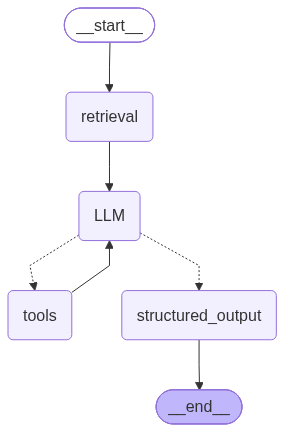

In [19]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

graph = StateGraph(QuestionAnswerState)

graph.add_node("retrieval", retrive)
graph.add_node("tools", ToolNode(tools))
graph.add_node("LLM", llm_tools)
graph.add_node("structured_output", structured_output)



graph.add_edge(START, "retrieval")
graph.add_edge("retrieval", "LLM")

graph.add_conditional_edges(
    "LLM",
    route_after_llm,
    {
        "tools": "tools",
        "structured_output": "structured_output"
    }
)

graph.add_edge("tools", "LLM")
# graph.add_edge("LLM","structured_output")
graph.add_edge("structured_output", END)

build = graph.compile(memory)
build


### Final answer Generate

In [20]:
from langchain_core.messages import HumanMessage 
config = {'configurable' : {
    'thread_id' : 'id_1'
}}
response = build.invoke({
    'messages':
    [HumanMessage(content="who is the prime minister of india?")]
},config=config)


result = response['final_answer']

print(result)


answer='Narendra Modi' sources=[] summary='The prime minister of India is Narendra Modi.'
